# TorchSpin — EPR Simulation Quickstart

**TorchSpin** is a differentiable PyTorch port of [EasySpin](https://easyspin.org/) for EPR/ESR spin Hamiltonian and spectrum simulation. This notebook demonstrates the core capabilities:

- Building spin systems (`SpinSystem`)
- Simulating powder CW EPR spectra (`pepper`)
- Simulating solution EPR spectra (`garlic`)
- Inspecting spin Hamiltonians (`ham`)
- Energy level diagrams

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchspin import (
    SpinSystem, Experiment, Options,
    pepper, garlic, ham,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Building a Spin System — Nitroxide Radical

A `SpinSystem` defines the magnetic properties of a paramagnetic center. Here we create a **nitroxide radical**: $S = 1/2$ electron coupled to a $^{14}$N nucleus ($I = 1$).

In [2]:
# S=1/2 electron with anisotropic g and 14N hyperfine
nitroxide = SpinSystem(
    S=[0.5],
    g=[[2.009, 2.006, 2.002]],
    Nucs=['14N'],
    A=[[10.0, 10.0, 95.0]],   # MHz — principal values
    lw=[1.0, 0.0],            # [Gaussian, Lorentzian] linewidth in mT
)

print(f"Electron spins: {nitroxide.nElectrons}")
print(f"Nuclear spins:  {nitroxide.nNuclei}")
print(f"Hilbert space:  {nitroxide.nStates} × {nitroxide.nStates}")
print(f"g-tensor:\n{nitroxide.g}")

Electron spins: 1
Nuclear spins:  1
Hilbert space:  6 × 6
g-tensor:
tensor([[2.0090, 2.0060, 2.0020]], dtype=torch.float64)


## 2. Powder EPR with `pepper`

`pepper` simulates **rigid-limit (powder) CW EPR spectra** by integrating over all molecular orientations on a spherical grid. This is the workhorse for solid-state / frozen-solution EPR.

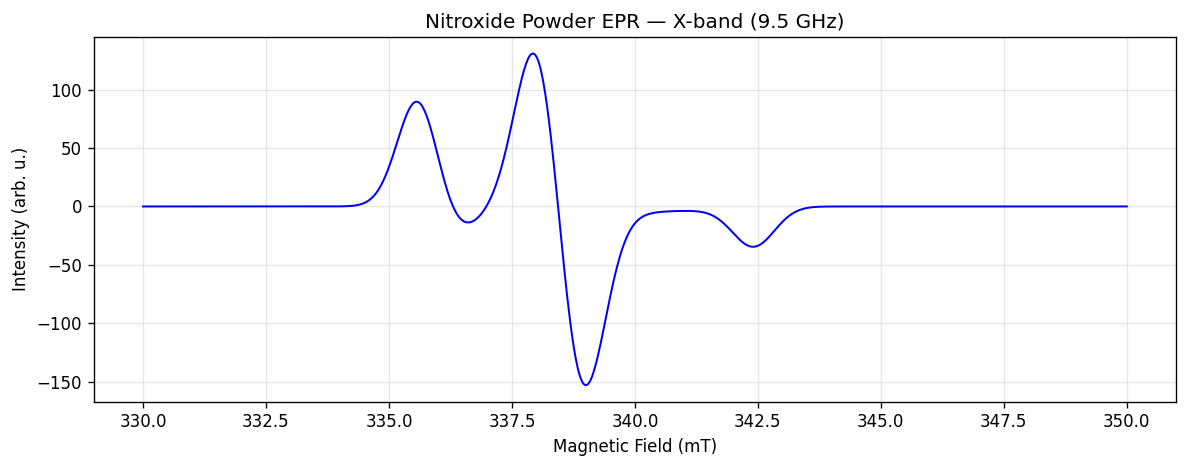

In [3]:
# X-band experiment: 9.5 GHz, sweep 330–350 mT
exp = Experiment(mwFreq=9.5, Range=[330, 350], nPoints=1024, Harmonic=1)
opt = Options(GridSize=50, Verbosity=0)

B, spec = pepper(nitroxide, exp, opt)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(B.numpy(), spec.numpy(), 'b', lw=1.2)
ax.set_xlabel('Magnetic Field (mT)')
ax.set_ylabel('Intensity (arb. u.)')
ax.set_title('Nitroxide Powder EPR — X-band (9.5 GHz)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Solution EPR with `garlic`

`garlic` simulates **fast-tumbling solution EPR spectra** where anisotropies are motionally averaged, producing sharp isotropic lines.

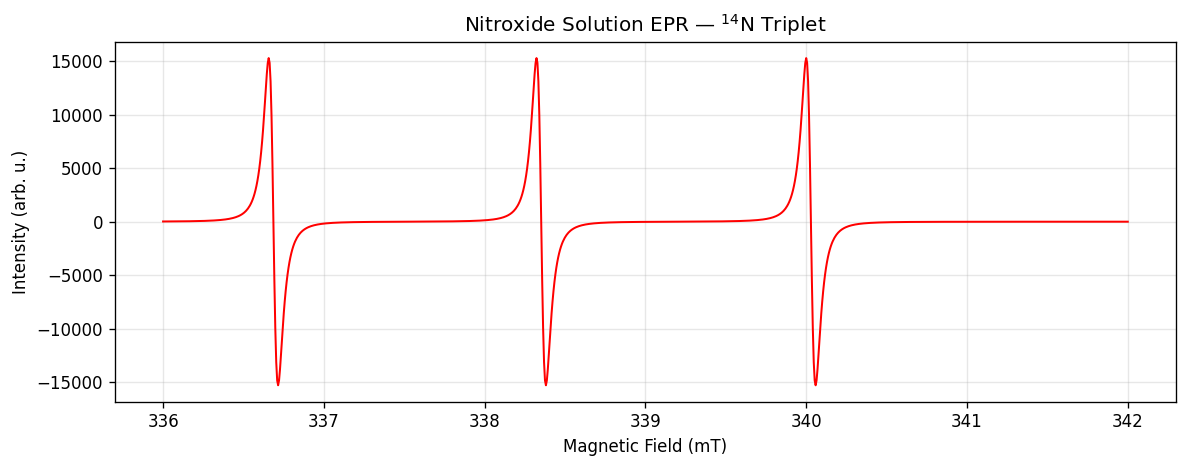

In [4]:
# Isotropic nitroxide in solution
sol_sys = SpinSystem(
    S=[0.5],
    g=[[2.006, 2.006, 2.006]],
    Nucs=['14N'],
    A=[[47.0, 47.0, 47.0]],   # isotropic A ≈ 47 MHz
    lw=[0.0, 0.1],            # pure Lorentzian linewidth
)
exp_sol = Experiment(mwFreq=9.5, Range=[336, 342], nPoints=1024, Harmonic=1)

B_sol, spec_sol = garlic(sol_sys, exp_sol)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(B_sol.numpy(), spec_sol.numpy(), 'r', lw=1.2)
ax.set_xlabel('Magnetic Field (mT)')
ax.set_ylabel('Intensity (arb. u.)')
ax.set_title('Nitroxide Solution EPR — $^{14}$N Triplet')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Copper(II) Complex — Multi-nucleus Powder EPR

A more complex example: **Cu(II)** with axial $g$ and hyperfine tensors plus $^{14}$N superhyperfine coupling from two coordinated nitrogen ligands.

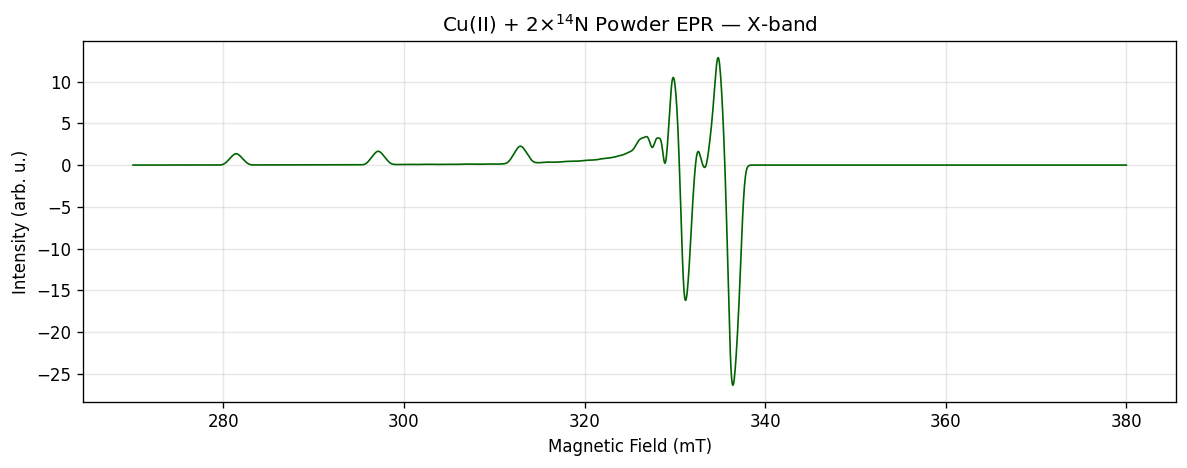

In [5]:
# Cu(II) with 63Cu + 2 × 14N
cu_sys = SpinSystem(
    S=[0.5],
    g=[[2.055, 2.055, 2.225]],
    Nucs=['63Cu', '14N', '14N'],
    A=[
        [40.0, 40.0, 490.0],   # 63Cu hyperfine (MHz)
        [14.0, 14.0, 14.0],    # 14N superhyperfine
        [14.0, 14.0, 14.0],
    ],
    lw=[0.8, 0.0],
)
exp_cu = Experiment(mwFreq=9.5, Range=[270, 380], nPoints=2048, Harmonic=1)
opt_cu = Options(GridSize=31, Verbosity=0)

B_cu, spec_cu = pepper(cu_sys, exp_cu, opt_cu)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(B_cu.numpy(), spec_cu.numpy(), 'darkgreen', lw=1.0)
ax.set_xlabel('Magnetic Field (mT)')
ax.set_ylabel('Intensity (arb. u.)')
ax.set_title('Cu(II) + 2×$^{14}$N Powder EPR — X-band')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Inspecting the Spin Hamiltonian

Use `ham()` to build the full spin Hamiltonian matrix $\hat{H}$ at a given magnetic field. When called with `B0=None`, it returns the field-independent and field-dependent components separately.

In [6]:
# Simple S=1/2 system
simple = SpinSystem(S=[0.5], g=[[2.0, 2.0, 2.0]])

# Full Hamiltonian at B0 = 340 mT along z
H = ham(simple, [0.0, 0.0, 340.0])
print(f"Hamiltonian shape: {H.shape}")
print(f"H (MHz):\n{H}")

# Eigenvalues = energy levels
energies = torch.linalg.eigvalsh(H.real)
print(f"\nEnergy levels at 340 mT: {energies} MHz")
print(f"Splitting: {(energies[1] - energies[0]):.2f} MHz")

Hamiltonian shape: torch.Size([2, 2])
H (MHz):
tensor([[ 4758.7233+0.j,     0.0000+0.j],
        [    0.0000+0.j, -4758.7233+0.j]], dtype=torch.complex128)

Energy levels at 340 mT: tensor([-4758.7233,  4758.7233], dtype=torch.float64) MHz
Splitting: 9517.45 MHz


## 6. Energy Level Diagram

Sweep the magnetic field and plot all energy eigenvalues to visualize Zeeman splitting and hyperfine interactions.

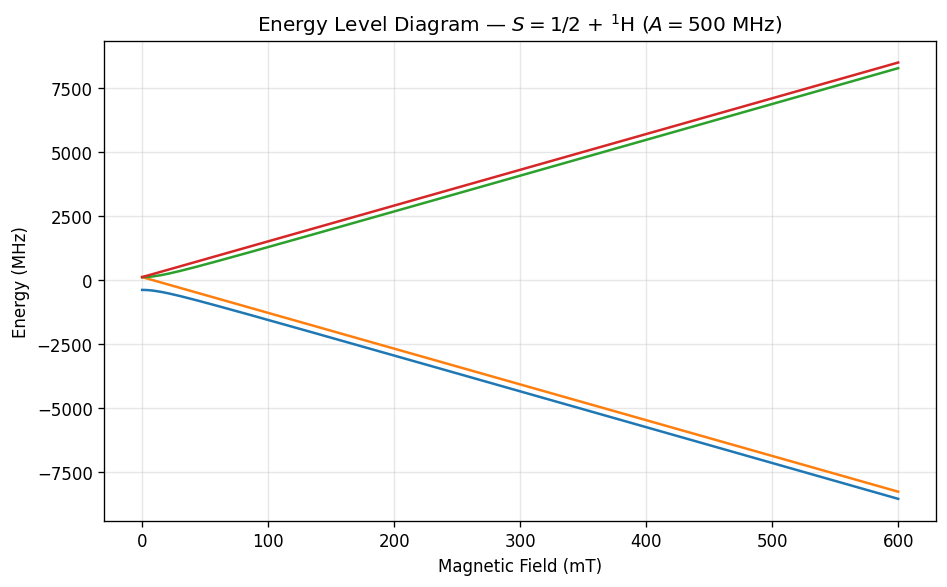

In [7]:
# S=1/2 + 1H — Zeeman + hyperfine
sys_hf = SpinSystem(S=[0.5], g=[[2.0, 2.0, 2.0]], Nucs=['1H'], A=[[500.0, 500.0, 500.0]])

B_sweep = torch.linspace(0, 600, 200)
E_all = []
for b in B_sweep:
    H_b = ham(sys_hf, [0.0, 0.0, float(b)])
    E_all.append(torch.linalg.eigvalsh(H_b.real))
E_all = torch.stack(E_all).numpy()

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(E_all.shape[1]):
    ax.plot(B_sweep.numpy(), E_all[:, i], lw=1.5)
ax.set_xlabel('Magnetic Field (mT)')
ax.set_ylabel('Energy (MHz)')
ax.set_title('Energy Level Diagram — $S = 1/2$ + $^{1}$H ($A = 500$ MHz)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

TorchSpin provides a Pythonic, **differentiable** EPR simulation engine:

| Function | Purpose |
|----------|---------|
| `SpinSystem` | Define paramagnetic centers (g-tensors, hyperfine, ZFS) |
| `pepper` | Rigid-limit powder CW EPR spectra |
| `garlic` | Fast-tumbling solution CW EPR spectra |
| `ham` | Direct spin Hamiltonian construction |

All tensors are native **PyTorch** — enabling GPU acceleration and automatic differentiation.  
See the next notebooks for GPU/autograd and spectral fitting examples.